# 04 오차 분석 — 어떤 물건에서 크게 틀렸고 왜

목적: 최종 모델(B1 + XGBoost 보정, 구간·신뢰도 보정)이 최종 검증 632건에서 **크게 틀린 물건의 공통점과 원인**을 찾고, 신뢰도가 그 물건들을 낮게 매기는지 확인한다. 판단은 `docs/의사결정/1007_13_오차_분석.md`.

- 대상: 노트북 02의 최종 검증 예측(`outputs/calibration_holdout_preds.csv`) 중 **보정 후·면적 있음**, 상황 A(처음 보는 건물)·B(같은 건물 과거 거래 있음)
- 대상 거래의 속성(거래유형·층·연식·공시가격 대비 위치)은 정제 데이터에서 붙인다. 재학습하지 않는다


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from avm import load_refs, add_location, SGG_NAME, BASE_DATE
from ml import load_buildings
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
OUT = ROOT / "outputs"
refs = load_refs(); t = refs.trades
p = pd.read_csv(OUT / "calibration_holdout_preds.csv", dtype={"pnu": str, "sgg_cd": str}, parse_dates=["deal_date"])
p = p[(p.구분 == "보정") & (~p.area_blank)].copy()
attr = t.drop_duplicates(["pnu", "deal_date", "price"])[["pnu", "deal_date", "price", "area_m2", "build_year", "house_type",
                                                        "dealing_type", "public_ratio", "outlier_z"]]
n0 = len(p)
p = p.merge(attr, on=["pnu", "deal_date", "price"], how="left", validate="many_to_one")
assert len(p) == n0 and p["dealing_type"].notna().all(), "대상 거래 속성 연결 실패"
p = p.join(load_buildings(t)[["elevator"]], on="pnu")
p = add_location(p, refs)
p["권역"] = p.sgg_cd.map(SGG_NAME)
p["연식"] = BASE_DATE.year - p.build_year
p["방향"] = np.where(p.log_err > 0, "높게", "낮게")
print(p.groupby("상황").size().to_dict())

{'A': 632, 'B': 632}


## 1. 전체 오차

In [2]:
def summ(g):
    return pd.Series({"n": len(g), "중앙값APE": g.ape.median(), "MAPE": g.ape.mean(), "±10%": (g.ape <= .1).mean(),
                      "±20%": (g.ape <= .2).mean(), "치우침(log 중앙값)": g.log_err.median(), "평균 신뢰도": g.confidence.mean(),
                      "80%구간포함": ((g.actual >= g.price_low) & (g.actual <= g.price_high)).mean()})
p.groupby("상황").apply(summ, include_groups=False).style.format("{:.3f}").format({"n": "{:.0f}"})

,n,중앙값APE,MAPE,±10%,±20%,치우침(log 중앙값),평균 신뢰도,80%구간포함
상황,,,,,,,,
A,632,0.093149,0.136826,0.528481,0.789557,-0.017487,0.758751,0.819620
B,632,0.089576,0.130171,0.545886,0.802215,-0.007930,0.788919,0.797468


## 2. 무엇이 오차를 키웠나 — 집단별

같은 표에 평균 신뢰도와 실제 ±20% 적중률을 함께 둔다. 둘이 비슷하면 신뢰도가 그 집단의 위험을 이미 반영하고 있다는 뜻

In [3]:
GROUPS = {
    "거래유형": p.dealing_type,
    "공시가격 대비 위치(수정 Z)": pd.cut(p.outlier_z, [-4, -1, 1, 20], labels=["싸게(z<-1)", "보통", "비싸게(z>1)"]),
    "층": pd.cut(p.floor, [-5, 0, 1, 4, 30], labels=["지하", "1층", "2~4층", "5층 이상"]),
    "연식": pd.cut(p.연식, [-1, 10, 20, 30, 60], labels=["10년 이하", "11~20년", "21~30년", "30년 초과"]),
    "실거래가": pd.cut(p.actual, [0, 1.5e8, 2.5e8, 4e8, 7e8, 9e9], labels=["1.5억 이하", "1.5~2.5억", "2.5~4억", "4~7억", "7억 초과"]),
    "권역": p.권역,
    "근거": p.tier,
    "ML 보정 배율": pd.cut(p.ml_factor, [0, .9, 1.1, 9], labels=["0.9 미만", "0.9~1.1", "1.1 초과"]),
}
rows = []
for name, key in GROUPS.items():
    g = p.groupby(["상황", key], observed=True).apply(summ, include_groups=False)
    rows.append(g.assign(구분=name).reset_index().rename(columns={key.name if key.name else 0: "집단"}))
tab = pd.concat(rows)
tab = tab.rename(columns={tab.columns[1]: "집단"})
tab.to_csv(OUT / "error_by_group.csv", index=False, encoding="utf-8-sig")
tab[tab.상황 == "B"].set_index(["구분", "집단"])[["n", "중앙값APE", "±20%", "치우침(log 중앙값)", "평균 신뢰도"]].style.format(
    {"n": "{:.0f}", "중앙값APE": "{:.1%}", "±20%": "{:.1%}", "치우침(log 중앙값)": "{:+.1%}", "평균 신뢰도": "{:.2f}"})

## 3. 가격대에 따른 치우침 — 평균으로 끌리는 경향

싼 물건은 높게, 비싼 물건은 낮게 추정한다. 강남의 낮은 추정(−5%대)은 강남만의 수준 차이가 아니라 강남에 비싼 거래가 많아서인지 확인

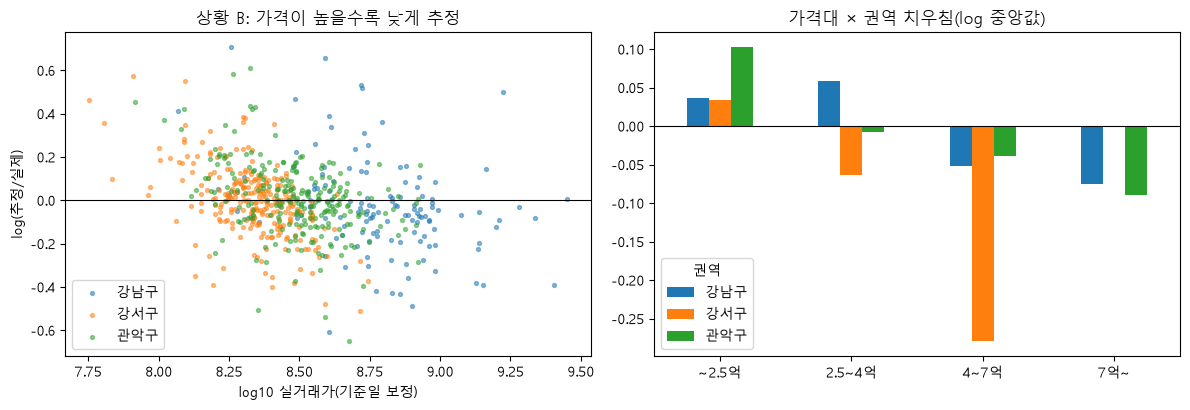

권역,강남구,강서구,관악구
actual,,,
~2.5억,+3.7%,+3.4%,+10.3%
2.5~4억,+5.8%,-6.4%,-0.7%
4~7억,-5.2%,-27.9%,-3.9%
7억~,-7.5%,+nan%,-8.9%


권역,강남구,강서구,관악구
actual,,,
~2.5억,9.0,173.0,69.0
2.5~4억,19.0,84.0,106.0
4~7억,52.0,5.0,53.0
7억~,53.0,NaN,9.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
b = p[p.상황 == "B"]
for name, g in b.groupby("권역"):
    axes[0].scatter(np.log10(g.actual), g.log_err.clip(-0.8, 0.8), s=8, alpha=0.5, label=name)
axes[0].axhline(0, color="k", lw=0.8); axes[0].set_xlabel("log10 실거래가(기준일 보정)"); axes[0].set_ylabel("log(추정/실제)")
axes[0].set_title("상황 B: 가격이 높을수록 낮게 추정"); axes[0].legend()
band = pd.cut(b.actual, [0, 2.5e8, 4e8, 7e8, 9e9], labels=["~2.5억", "2.5~4억", "4~7억", "7억~"])
pv = b.pivot_table(index=band, columns="권역", values="log_err", aggfunc="median", observed=True)
pv.plot.bar(ax=axes[1], rot=0); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("가격대 × 권역 치우침(log 중앙값)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()
display(pv.style.format("{:+.1%}"))
display(b.pivot_table(index=band, columns="권역", values="log_err", aggfunc="size", observed=True))

## 4. 오차 상위 사례와 원인 (상황 B)

원인 표시는 규칙으로 붙인다: 직거래, 공시가격 대비 이례적으로 싸거나 비싼 거래(|z|>1), 지하, 30년 초과, 같은 건물 근거 없음, ML 보정 배율 1.1 초과

In [5]:
def causes(r):
    c = []
    if r.dealing_type == "직거래": c.append("직거래")
    if r.outlier_z < -1: c.append("공시 대비 싸게 거래")
    if r.outlier_z > 1: c.append("공시 대비 비싸게 거래")
    if r.floor < 0: c.append("지하")
    if r.연식 > 30: c.append("30년 초과")
    if r.tier != "같은 건물": c.append("같은 건물 근거 없음")
    if r.ml_factor > 1.1 or r.ml_factor < 0.9: c.append("ML 보정 큼")
    return ", ".join(c) or "—"
top = b.sort_values("ape", ascending=False).head(15).copy()
top["원인"] = top.apply(causes, axis=1)
top_out = top[["권역", "dong", "deal_date", "area_m2", "floor", "연식", "actual", "price_est", "ape", "방향", "confidence", "tier",
               "dealing_type", "public_ratio", "원인"]]
top_out.to_csv(OUT / "error_top_cases.csv", index=False, encoding="utf-8-sig")
top_out.style.format({"actual": "{:,.0f}", "price_est": "{:,.0f}", "ape": "{:.1%}", "confidence": "{:.2f}", "public_ratio": "{:.2f}",
                      "area_m2": "{:.1f}", "deal_date": "{:%Y-%m-%d}"})

,권역,dong,deal_date,area_m2,floor,연식,actual,price_est,ape,방향,confidence,tier,dealing_type,public_ratio,원인
1197,강남구,대치동,2026-08-22,24.7,5,23,"180,000,000","365,081,505",102.8%,높게,0.80,같은 건물,중개거래,1.13,공시 대비 싸게 거래
911,강남구,청담동,2026-04-13,37.2,2,37,"388,857,191","748,684,843",92.5%,높게,0.79,같은 건물,직거래,0.87,"직거래, 공시 대비 싸게 거래, 30년 초과"
1010,관악구,봉천동,2026-05-20,60.1,3,17,"210,458,113","388,079,604",84.4%,높게,0.89,법정동,직거래,0.96,"직거래, 공시 대비 싸게 거래, 같은 건물 근거 없음"
941,관악구,봉천동,2026-04-23,68.7,1,34,"184,258,425","330,257,621",79.2%,높게,0.86,법정동,직거래,1.02,"직거래, 공시 대비 싸게 거래, 30년 초과, 같은 건물 근거 없음"
1057,강서구,화곡동,2026-06-16,32.7,2,36,"80,874,201","143,722,080",77.7%,높게,0.80,법정동,중개거래,0.98,"공시 대비 싸게 거래, 30년 초과, 같은 건물 근거 없음"
1122,강서구,화곡동,2026-07-14,30.0,7,14,"124,192,857","215,305,888",73.4%,높게,0.86,같은 건물,직거래,0.95,"직거래, 공시 대비 싸게 거래"
1228,강남구,개포동,2026-09-07,69.5,5,23,"522,560,000","888,814,768",70.1%,높게,0.79,법정동,직거래,1.34,"직거래, 공시 대비 싸게 거래, 같은 건물 근거 없음"
881,강남구,대치동,2026-03-26,72.7,5,23,"526,877,803","884,173,827",67.8%,높게,0.71,법정동,직거래,1.18,"직거래, 공시 대비 싸게 거래, 같은 건물 근거 없음"
710,강남구,삼성동,2025-12-17,122.1,2,34,"1,677,753,473","2,768,007,118",65.0%,높게,0.68,법정동,직거래,1.21,"직거래, 공시 대비 싸게 거래, 30년 초과, 같은 건물 근거 없음"
802,강남구,역삼동,2026-02-11,55.5,2,33,"305,709,414","487,045,155",59.3%,높게,0.62,법정동,중개거래,1.29,"공시 대비 싸게 거래, 30년 초과, 같은 건물 근거 없음, ML 보정 큼"


In [6]:
b2 = b.assign(원인=b.apply(causes, axis=1))
big = b2[b2.ape > 0.2]
cnt = pd.Series([c for s in big.원인 for c in s.split(", ")]).value_counts()
print(f"±20% 밖 {len(big)}건 중 원인 표시 비율(한 건에 여러 원인)")
(cnt / len(big)).round(3)

±20% 밖 125건 중 원인 표시 비율(한 건에 여러 원인)


같은 건물 근거 없음     0.416
공시 대비 비싸게 거래    0.400
공시 대비 싸게 거래     0.368
30년 초과          0.352
ML 보정 큼         0.280
직거래             0.272
지하              0.152
—               0.072
Name: count, dtype: float64

## 5. 신뢰도가 위험을 반영하나 — 신뢰도 구간별 실제 적중률

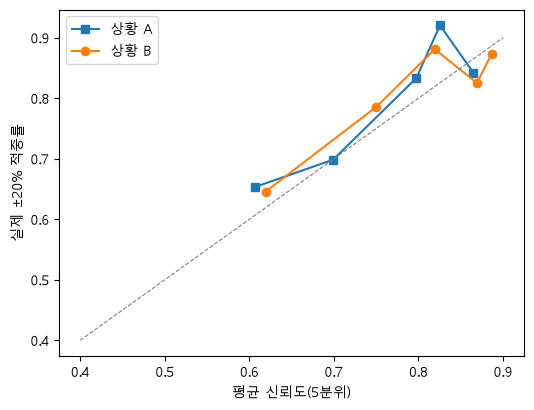

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for sc, mk in [("A", "s"), ("B", "o")]:
    g = p[p.상황 == sc]
    r = g.groupby(pd.qcut(g.confidence.rank(method="first"), 5), observed=True).agg(conf=("confidence", "mean"), hit=("ape", lambda v: (v <= .2).mean()))
    ax.plot(r.conf, r.hit, marker=mk, label=f"상황 {sc}")
ax.plot([0.4, 0.9], [0.4, 0.9], color="gray", ls="--", lw=0.8)
ax.set_xlabel("평균 신뢰도(5분위)"); ax.set_ylabel("실제 ±20% 적중률"); ax.legend(); plt.show()

## 6. 학습 기간 (3년 / 5년 / 6년)

같은 최종 모델 경로(`run_holdout(ml=True)`)로 학습 거래 기간만 바꿔 같은 검증 632건에서 비교. 결과는 `milestones/train_period/`

In [8]:
per = pd.read_csv(sorted((ROOT / "milestones" / "train_period").glob("*/metrics.csv"))[-1])
per.set_index(["학습기간", "상황"])[["학습거래", "중앙값APE", "MAPE", "±10%", "±20%", "같은건물근거"]].style.format(
    {"학습거래": "{:,.0f}", "중앙값APE": "{:.1%}", "MAPE": "{:.1%}", "±10%": "{:.1%}", "±20%": "{:.1%}", "같은건물근거": "{:.1%}"})

## 7. 관찰

수치는 위 표에서 읽고, 원인 해석·개선 판단·한계는 `docs/의사결정/1007_13_오차_분석.md`에 정리한다.